<a href="https://colab.research.google.com/github/Vimukthi-Nuwan/Deep_Learning/blob/Experiment/Amazon_Review_Classifier/NLP_Final_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📌 Step 1: Install required libraries

In [ ]:
!pip install nltk
!pip install wget

### 📌 Step 2: Load necessary Python libraries

In [ ]:
import time
start_time = time.time()  # Track execution time

import os
import re
import keras
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, Sequential
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed, Bidirectional, Flatten, Dropout, BatchNormalization, SpatialDropout1D

# Download necessary NLTK data
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vimukthimadhushanka/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 📌 Step 3: Configure display settings and ignore warnings

In [ ]:
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore")

### 📌 Step 4: Load the dataset

In [ ]:
data = pd.read_csv("AmazonReviews.csv")

### 📌 Step 5: Explore the dataset

🔹 Print number of text reviews

In [ ]:
print(data['Text'].shape)

(568454,)


🔹 Display first few rows

In [ ]:
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labr...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,"Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as ""Jumbo""."
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with ..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda. The fl...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,"Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."


🔹 Select relevant columns and display sample data

In [ ]:
data[['Score', 'Text', 'Summary']].sample(5)

,Score,Text,Summary
495391,5,The first time I ate these chips was in Aruba in 2007. I couldn't find them in our area (CT) so you can imagine my joy when I found them on Amazon. I love these and hope you continue to carry th...,Don't stop carrying these chips
152036,5,"In my search to find yummy treats for my dog, that don't make him sick, I stumbled upon happy hips, which is perfect since my dog is a lab mix predisposed to hip problems. He loves them!! In fac...",happy owner!
326658,5,we love all the k-cups we have received from amazon. timothy's decaf is the greastest.,lover og k-cups
364223,5,"This is a very good spice. I found it at our local grocery store and liked it right away. My husband likes it VERY much. He tries it on everything. We use it for fajitas, fried potatos, hot sauce,...",ummm good
80044,5,"I read about this in a magazine. It was recommended for weight loss, and cholestrol control. I don't know if it helped so much with my weight loss, but it did lower my cholstrol by 20 points!My Dr...",Happy with this


### 📌 Step 6: Remove duplicates and missing values

In [ ]:
data.drop_duplicates(subset=['Text'], inplace = True)
data.dropna(axis = 0, inplace = True)

### 📌 Step 7: Label encoding - Convert review scores into binary labels (positive/negative)

In [ ]:
labels = data['Score']
labels[labels < 4] = 0  # Negative sentiment (1,2,3)
labels[labels > 1] = 1  # Positive sentiment (4,5)

### 📌 Step 8: Define a dictionary to expand contractions (e.g., "don't" → "do not")

In [ ]:
contraction_mapping = {"ain't": "is not", "aren't": "are not","can't": "can not", "'cause": "because", "could've": "could have", "couldn't": "could not",

                           "didn't": "did not", "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",

                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",

                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",

                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",

                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",

                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",

                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",

                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",

                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",

                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",

                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",

                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",

                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",

                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",

                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",

                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",

                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",

                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",

                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",

                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",

                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",

                           "you're": "you are", "you've": "you have"
                        }

### 📌 Step 9: Define function to clean text (remove punctuation, stopwords, and contractions)

In [ ]:
def text_cleaner(text):
    newString = text.lower()
    newString = BeautifulSoup(newString, "lxml").text  # Remove HTML tags
    newString = re.sub(r'\([^)]*\)', '', newString)  # Remove content in parentheses
    newString = re.sub('"', '', newString)  # Remove double quotes
    newString = ' '.join([contraction_mapping[t] if t in contraction_mapping else t for t in newString.split(" ")])
    newString = re.sub(r"'s\b", "", newString)  # Remove possessive apostrophe
    newString = re.sub("[^a-zA-Z]", " ", newString)  # Remove non-alphabetic characters
    tokens = [w for w in newString.split() if not w in stop_words]  # Remove stopwords
    long_words = [i for i in tokens if len(i) >= 3]  # Remove short words
    return (" ".join(long_words)).strip()

### 📌 Step 10: Define function to clean summaries (remove punctuation and contractions)

In [ ]:
def summary_cleaner(text):
    newString = re.sub('"', '', text)
    newString = ' '.join([contraction_mapping[t] if t in contraction_mapping else t for t in newString.split(" ")])
    newString = re.sub(r"'s\b", "", newString)
    newString = re.sub("[^a-zA-Z]", " ", newString)
    newString = newString.lower()
    return " ".join([i for i in newString.split() if len(i) > 1])

### 📌 Step 11: Store cleaned text and summaries in dataset

In [ ]:
data['cleaned_text'] = [text_cleaner(t) for t in data['Text']]
data['cleaned_summary'] = [summary_cleaner(t) for t in data['Summary']]
data.dropna(axis = 0, inplace = True)
data['cleaned_summary'] = data['cleaned_summary'].apply(lambda x: '_START_ ' + x + ' _END_')

### 📌 Step 12: Print the first 5 reviews, their summaries, and scores

In [ ]:
for i in range(5):
    print("Review:", data['cleaned_text'][i])
    print("Summary:", data['cleaned_summary'][i])
    print("Score:", data['Score'][i])
    print("\n")

Review: bought several vitality canned dog food products found good quality product looks like stew processed meat smells better labrador finicky appreciates product better
Summary: _START_ good quality dog food _END_
Score: 1


Review: product arrived labeled jumbo salted peanuts peanuts actually small sized unsalted sure error vendor intended represent product jumbo
Summary: _START_ not as advertised _END_
Score: 0


Review: confection around centuries light pillowy citrus gelatin nuts case filberts cut tiny squares liberally coated powdered sugar tiny mouthful heaven chewy flavorful highly recommend yummy treat familiar story lewis lion witch wardrobe treat seduces edmund selling brother sisters witch
Summary: _START_ delight says it all _END_
Score: 1


Review: looking secret ingredient robitussin believe found got addition root beer extract ordered made cherry soda flavor medicinal
Summary: _START_ cough medicine _END_
Score: 0


Review: great taffy great price wide assortment yum

### 📌 Step 13: Plot histograms for text and summary lengths

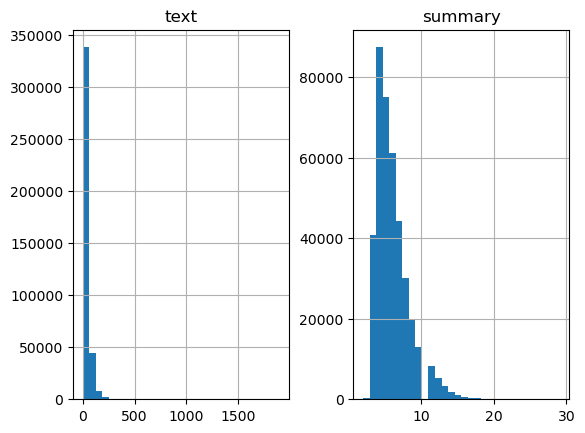

In [ ]:
text_word_count = [len(i.split()) for i in data['cleaned_text']]
summary_word_count = [len(i.split()) for i in data['cleaned_summary']]

length_df = pd.DataFrame({'text': text_word_count, 'summary': summary_word_count})
length_df.hist(bins = 30)
plt.show()

### 📌 Step 14: Split dataset into training and validation sets

In [ ]:
x_tr, x_val, y_tr, y_val = train_test_split(data['cleaned_text'], data['Score'], test_size = 0.1, random_state = 0, shuffle = True)

### 📌 Step 15: Tokenization of text data

In [ ]:
max_words = 1000  # Limit vocabulary size

x_tokenizer = Tokenizer(num_words = max_words, lower = True, split = ' ')
x_tokenizer.fit_on_texts(list(x_tr))

### 📌 Step 16: Convert text into integer sequences and pad them

In [ ]:
max_len_text = 80
x_tr = pad_sequences(x_tokenizer.texts_to_sequences(x_tr), maxlen = max_len_text, padding = 'post')
x_val = pad_sequences(x_tokenizer.texts_to_sequences(x_val), maxlen = max_len_text, padding = 'post')

x_voc_size = len(x_tokenizer.word_index) + 1

### 📌 Step 17: Build LSTM Model

In [ ]:
inputs = Input(shape=(80,))
embedding = Embedding(input_dim=x_voc_size, output_dim=300, input_length=80, trainable=True)(inputs)

x = SpatialDropout1D(0.3)(embedding)
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x)
x = BatchNormalization()(x)

x = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(x)
x = BatchNormalization()(x)

x = Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs, output)
model.compile(
    loss='binary_crossentropy',
    optimizer=AdamW(learning_rate=1e-4, weight_decay=1e-4),
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 80, 300)        │    34,551,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 80, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 80, 256)        │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,078,877 (133.82 MB)

 Trainable params: 35,078,237 (133.81 MB)

 Non-trainable params: 640 (2.50 KB)

### 📌 Step 18: Define learning rate scheduler

In [ ]:
lr_scheduler = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 2, min_lr = 1e-6)

### 📌 Step 19: Train the model

In [ ]:
history = model.fit(x_tr, y_tr, validation_data = (x_val, y_val), epochs = 15, batch_size = 128, verbose = 1, callbacks = [lr_scheduler])

Epoch 1/15
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 2292s 827ms/step - accuracy: 0.7113 - loss: 0.6134 - val_accuracy: 0.7801 - val_loss: 0.5306 - learning_rate: 1.0000e-04
Epoch 2/15
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 2312s 835ms/step - accuracy: 0.7807 - loss: 0.5312 - val_accuracy: 0.8411 - val_loss: 0.3617 - learning_rate: 1.0000e-04
Epoch 3/15
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 2329s 841ms/step - accuracy: 0.8427 - loss: 0.3774 - val_accuracy: 0.8079 - val_loss: 0.5069 - learning_rate: 1.0000e-04
Epoch 4/15
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 2356s 851ms/step - accuracy: 0.8491 - loss: 0.3658 - val_accuracy: 0.8636 - val_loss: 0.3218 - learning_rate: 1.0000e-04
Epoch 5/15
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 2309s 834ms/step - accuracy: 0.8602 - loss: 0.3326 - val_accuracy: 0.8672 - val_loss: 0.3135 - learning_rate: 1.0000e-04
Epoch 6/15
2768/2768 ━━━━━━━━━━━━━━━━━━━━ 2340s 845ms/step - accuracy: 0.8643 - loss: 0.3259 - val_accuracy: 0.8679 - val_loss: 0.3105 - learning_rate: 1.0000e-04
Epoch 7/15
2768/2768 ━

### 📌 Step 20: Plot Training History (Accuracy & Loss)

🔹 Plot Training and Validation Accuracy Over Epochs

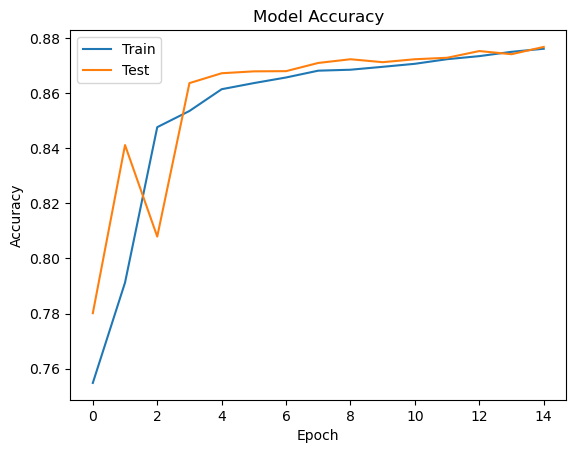

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc = 'upper left')
plt.show()

🔹 Plot Training and Validation Loss Over Epochs

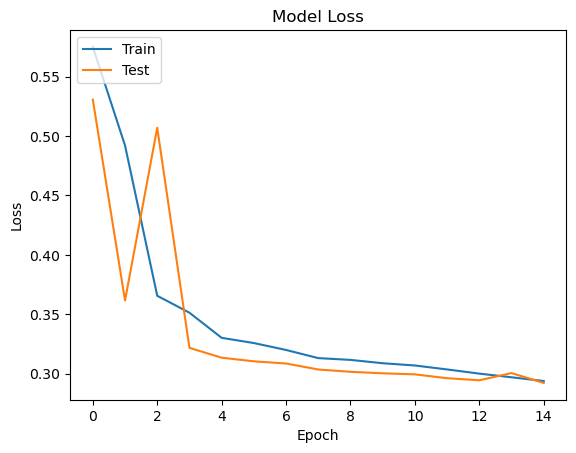

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc = 'upper left')
plt.show()

### 📌 Step 21: Evaluate final model

In [ ]:
scores = model.evaluate(x_val, y_val, verbose = 0)
print(f"Accuracy: {scores[1] * 100:.2f}%")

Accuracy: 87.68%


### 📌 Step 22: Print execution time

In [ ]:
end_time = time.time()
print(f"Time taken: {(end_time - start_time)/60:.2f} minutes to train model.")

Time taken: 512.74 minutes to train model.
